# Compute scaling on the particle impact model

Investigate the particle impact model proposed by Tsai and Hirth (2020):

Tsai, V. C., & Hirth, G. (2020). Elastic impact consequences for high-frequency earthquake ground motion. Geophysical Research Letters, 47, e2019GL086302. https://doi.org/10.1029/2019GL086302

2025.11.22 Kurama Okubo

In [2]:
import os
import obspy
from obspy import read, Stream, Trace
from scipy import signal, stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl
from matplotlib.ticker import FixedLocator
%matplotlib inline
import glob
from glob import glob
import numpy as np
import mpmath as mp
import pandas as pd
import datetime
from datetime import timedelta
from tqdm import tqdm
import warnings

from matplotlib import gridspec

from scipy import interpolate
from scipy.optimize import curve_fit  
import matplotlib as mpl
import pickle
import copy

import seaborn as sns 
from scipy.interpolate import LSQUnivariateSpline
from scipy import integrate
from scipy.interpolate import CubicSpline

import h5py # store the STF in hdf5
from scipy.optimize import minimize

from shapely.geometry import Point # use to find the data in the interval
from shapely.geometry.polygon import Polygon


# from STFfit_func import *

plt.rcParams["font.family"] = 'Arial'
# plt.rcParams["font.sans-serif"] = "DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif"
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4.75
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.size"] = 3
plt.rcParams["xtick.minor.width"] = 0.4
plt.rcParams["xtick.minor.visible"] = True

plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.major.size"] = 4.75
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.size"] = 3
plt.rcParams["ytick.minor.width"] = 0.4
plt.rcParams["ytick.minor.visible"] = True

plt.rcParams["savefig.transparent"] = False #True
plt.rcParams['axes.linewidth'] = 0.75

from obspy.core.utcdatetime import UTCDateTime  
os.environ['TZ'] = 'GMT' # change time zone to avoid confusion in unix_tvec conversion
UTCDateTime.DEFAULT_PRECISION = 8

In [4]:
datadir = "./"
if not os.path.exists(datadir):
    os.makedirs(datadir)

figdir = "./"
if not os.path.exists(figdir):
    os.makedirs(figdir)


# Particle impact model

## Theory

$$
[
T_c \approx 2.9 \left( \frac{m^2}{R E_*^2 V_z} \right)^{1/5}
      \approx 2.9 \left( \frac{16\pi^2 \rho^2 \xi^4}{9 E_*^2 V_z} \right)^{1/5} R
      \approx 0.014\, \frac{\mathrm{s}}{\mathrm{m}} \, R ,
]
$$

According to the Text S3 of VH2020, the effective radius is appropriate with $D_{73}$, rather than $D_{50}$.

We compute the $T_c$ in the following process flow:

1. Compute $D_{73}$ from Supplementary figure S10d in the manuscript
2. Substitute to the approximation to compute $T_c$.

## Compute $D_{73}$

See `Experiments/GougePatch/Gouge_ParticleSize/plot_Gauge_ParticleDistribution.ipynb`.

In [47]:
# Read particle diameter file
datarootdir = "../../../Experiments/GougePatch/Gouge_ParticleSize"
df_check = pd.read_csv(f"{datarootdir}/gouge_diameter_rock_T-3_Run_200um_pass.csv", index_col=0)

In [50]:
df_check.head

<bound method NDFrame.head of     diameter[um]  frequency  cumulative_volume
0         0.0400     0.0000             0.0000
1         0.0450     0.0000            -0.0004
2         0.0506     0.0001            -0.0007
3         0.0570     0.0034             0.0010
4         0.0641     0.0094             0.0074
..           ...        ...                ...
76      311.9784     0.0000           100.0000
77      351.0232     0.0000           100.0000
78      394.9547     0.0000           100.0000
79      444.3842     0.0000           100.0000
80      500.0000     0.0000           100.0000

[81 rows x 3 columns]>

In [73]:
# To match the original calculation of D50, we adjust the relationship between diameter and  cumulative_volume.
xs = df_check["diameter[um]"].values
qs_cumtrapz = df_check["cumulative_volume"].values[1:]

In [76]:
d10 = xs[np.where(qs_cumtrapz >= 10)[0][0]]
d50 = xs[np.where(qs_cumtrapz >= 50)[0][0]]
d90 = xs[np.where(qs_cumtrapz >= 90)[0][0]]
print("The diameter is :", d10, d50, d90, d73)

The diameter is : 1.5474 8.0644 23.3063 14.5422


In [78]:
d73 = xs[np.where(qs_cumtrapz >= 73)[0][0]]
print(f"D_{73} = {d73:.2f} μm.")

D_73 = 14.54 μm.


(0.0, 105.0)

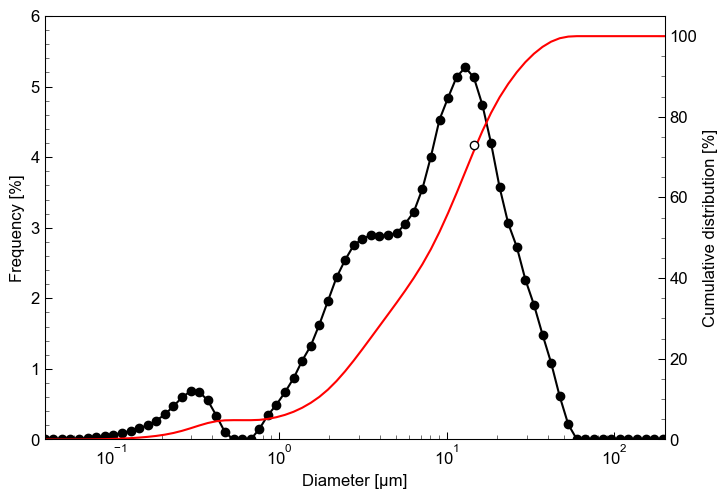

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
ax.plot(df_check["diameter[um]"], df_check["frequency"], "ko-")

ax.set_ylim([0, 6])
ax.set_xlim([0.04, 200])
ax.set_xlabel("Diameter [µm]")
ax.set_ylabel("Frequency [%]")

ax2 = ax.twinx()
ax2.plot(df_check["diameter[um]"], df_check["cumulative_volume"], "r-")
ax2.plot(d73, 73, "o",  markerfacecolor="w", markeredgecolor="k")


# plot cumulative volume
ax2.set_xscale('log')
ax2.set_ylabel('Cumulative distribution [%]')
ax2.set_ylim([0, 105])

## Compute spectra using the property of gouge used for the patch

In [89]:
R73 = d73*1e-6/2 # [μs] -> [m]
Tc = 0.014 * R73
fc = 1/Tc
print(f"Tc = {Tc*1e6:.3f} μs, Thus fc = {1/Tc/1e6:.3f} MHz.")

Tc = 0.102 μs, Thus fc = 9.824 MHz.


**Summary:**

The estimated characteristic frequency is approximately 10 MHz, which is far higher than the frequencies observed in our source spectra. Although the actual source spectra may include energy in this range, our AE sensors do not measure frequencies this high, so this component cannot be detected in the present dataset.